# Визуализация Elliptic Data Set

Этот ноутбук нужен для первичного понимания структуры `Elliptic Data Set`.

Источник данных:
- Kaggle: `https://www.kaggle.com/datasets/ellipticco/elliptic-data-set/data`

Что здесь есть:
- обзор таблиц и разметки;
- временная структура данных;
- базовые свойства графа транзакций;
- связность и длины путей;
- центральности узлов;
- подграфы по классам;
- визуализация сообществ.

In [1]:
"""
назначение: EDA и визуализация структуры Elliptic Data Set.
основные шаги: загрузка таблиц, обзор разметки и временной структуры,
построение sampled-графа, анализ связности, центральностей, сообществ
и двумерных проекций признаков узлов.
зависимости и данные: pandas, numpy, matplotlib, seaborn, networkx,
sklearn, файлы elliptic_txs_features.csv, elliptic_txs_classes.csv,
elliptic_txs_edgelist.csv.
"""

from __future__ import annotations

from pathlib import Path
import random
import warnings

import matplotlib.pyplot as plt
from matplotlib import colors as mcolors
import networkx as nx
from networkx.algorithms import community as nx_community
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.float_format", lambda value: f"{value:.4f}")

## 1. Конфигурация

Задаём режим работы, пути, стиль графиков и параметры выборки для графовых визуализаций.

Полный граф слишком большой для наглядного рисунка, поэтому для network-визуализаций ниже используется стратифицированная выборка.

In [ ]:
# текущая директория нужна, чтобы ноутбук одинаково работал из корня проекта, папки notebooks и kaggle.
CURRENT_DIR = Path.cwd().resolve()
if CURRENT_DIR.name == "notebooks" and CURRENT_DIR.parent.name == "BITOC_WORK":
    BASE_DIR = CURRENT_DIR.parent
elif (CURRENT_DIR / "BITOC_WORK").exists():
    BASE_DIR = CURRENT_DIR / "BITOC_WORK"
else:
    BASE_DIR = CURRENT_DIR

# флаг окружения переключает источник данных между kaggle и локальной структурой проекта.
WORK_IN_KAGGLE = False
DATA_ROOT = Path("data/raw") if WORK_IN_KAGGLE else BASE_DIR / "data" / "raw"

# директории ниже разделяют входные данные, графики и табличные результаты eda.
NOTEBOOK_NAME = "00_visualization_elliptic"
OUTPUT_DIR = BASE_DIR / "visualizations" / "figures" / NOTEBOOK_NAME
TABLE_DIR = BASE_DIR / "data" / "task_datasets" / NOTEBOOK_NAME

DATA_ROOT.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

# основные параметры фиксируют воспроизводимость, размер sample-графа и объем дорогих расчетов.
RANDOM_STATE = 42
GRAPH_SAMPLE_FRAC = 0.05
TOP_N_CENTRALITY = 10
TSNE_SUBSET_SIZE = 5000


# вход: seed
# выход: фиксированные генераторы python и numpy для повторяемых выборок.
def set_seed(seed: int = RANDOM_STATE) -> None:
    random.seed(seed)
    np.random.seed(seed)


# выход: единый стиль графиков для всех последующих визуализаций.
def setup_plot_style() -> None:
    sns.set_theme(style="whitegrid", context="notebook")
    plt.rcParams["figure.figsize"] = (10, 5)


# вход: объект matplotlib и имя файла
# выход: показанный график и png в output_dir.
def render_figure(fig, filename: str | None = None) -> None:
    if filename:
        fig.savefig(OUTPUT_DIR / filename, dpi=150, bbox_inches="tight")
    display(fig)
    plt.close(fig)


# вход: dataframe и имя csv
# выход: сохраненная таблица для дальнейшей вставки в отчет.
def save_frame(frame: pd.DataFrame, filename: str) -> None:
    frame.to_csv(TABLE_DIR / filename, index=False)


set_seed()
setup_plot_style()

print(str(BASE_DIR))
print(str(DATA_ROOT))
print(str(OUTPUT_DIR))
print(str(TABLE_DIR))

/kaggle/working
/kaggle/working/data/raw
/kaggle/working/visualizations/figures/00_visualization_elliptic
/kaggle/working/data/task_datasets/00_visualization_elliptic


In [ ]:
# вход: имя файла elliptic
# выход: первый найденный путь или none, если файл отсутствует.
def find_standard_file(filename: str) -> Path | None:
    search_roots = [
        DATA_ROOT,
        BASE_DIR / "data",
        BASE_DIR,
        BASE_DIR.parent / "data",
        BASE_DIR.parent,
    ]

    # direct_candidates хранит типовые расположения датасета до более дорогого рекурсивного поиска.
    direct_candidates = []
    for root in search_roots:
        if not root.exists():
            continue
        direct_candidates.extend(
            [
                root / filename,
                root / "elliptic" / filename,
                root / "elliptic_data" / filename,
                root / "elliptic-data-set" / filename,
                root / "Elliptic" / filename,
                root / "Elliptic Data Set" / filename,
                root / "elliptic_bitcoin_dataset" / filename,
            ]
        )

    for candidate in direct_candidates:
        if candidate.exists():
            return candidate

    for root in search_roots:
        if root.exists():
            matches = sorted(root.rglob(filename))
            if matches:
                return matches[0]
    return None


# выход: словарь с путями к трем обязательным таблицам features, classes и edges.
def resolve_elliptic_paths() -> dict[str, Path]:
    paths = {
        "features": find_standard_file("elliptic_txs_features.csv"),
        "classes": find_standard_file("elliptic_txs_classes.csv"),
        "edges": find_standard_file("elliptic_txs_edgelist.csv"),
    }
    missing = [name for name, path in paths.items() if path is None]
    if missing:
        raise FileNotFoundError(
            "Не найдены файлы Elliptic: "
            + ", ".join(missing)
            + f". Проверьте DATA_ROOT: {DATA_ROOT}"
        )
    return {name: Path(path) for name, path in paths.items()}


# вход: исходная метка из classes
# выход: единое имя класса для анализа и графиков.
def normalize_label(value: str) -> str:
    text = str(value).strip().lower()
    if text == "1":
        return "illicit"
    if text == "2":
        return "licit"
    return "unknown"


# вход: граф и лимит стартовых вершин
# выход: выборка длин кратчайших путей без полного all-pairs расчета.
def sample_shortest_path_lengths(
    graph: nx.Graph,
    max_sources: int = 150,
    seed: int = RANDOM_STATE,
) -> list[int]:
    nodes = list(graph.nodes())
    if not nodes:
        return []

    rng = np.random.default_rng(seed)
    if len(nodes) > max_sources:
        source_nodes = rng.choice(nodes, size=max_sources, replace=False)
    else:
        source_nodes = nodes

    path_lengths = []
    for source in source_nodes:
        lengths = nx.single_source_shortest_path_length(graph, source)
        path_lengths.extend(lengths.values())
    return path_lengths


# вход: словарь центральности
# выход: таблица top_n узлов по заданной метрике.
def build_top_centrality_frame(
    centrality_dict: dict[int, float],
    metric_name: str,
    top_n: int = TOP_N_CENTRALITY,
) -> pd.DataFrame:
    top_items = sorted(
        centrality_dict.items(),
        key=lambda item: item[1],
        reverse=True,
    )[:top_n]
    return pd.DataFrame(top_items, columns=["tx_id", metric_name])


# вход: список множеств вершин
# выход: отображение tx_id в номер найденного сообщества.
def assign_community_ids(communities: list[set[int]]) -> dict[int, int]:
    community_map = {}
    for community_id, nodes in enumerate(communities):
        for node in nodes:
            community_map[int(node)] = int(community_id)
    return community_map

## 2. Загрузка данных

Загружаем три стандартные таблицы Elliptic:
- признаки транзакций;
- классы транзакций;
- список рёбер между транзакциями.

In [ ]:
# хранит физические пути к таблицам, которые дальше объединяются по tx_id.
elliptic_paths = resolve_elliptic_paths()

# содержит идентификатор транзакции, временной шаг и анонимизированные признаки узла.
features_df = pd.read_csv(elliptic_paths["features"], header=None)
feature_cols = [f"feature_{idx:03d}" for idx in range(features_df.shape[1] - 2)]
features_df.columns = ["tx_id", "time_step"] + feature_cols
features_df["tx_id"] = features_df["tx_id"].astype(int)
features_df["time_step"] = features_df["time_step"].astype(int)

# хранит исходную разметку, а class_mapped переводит ее в unknown, licit и illicit.
classes_df = pd.read_csv(elliptic_paths["classes"]).rename(
    columns={"txId": "tx_id", "class": "raw_class"}
)
classes_df["tx_id"] = classes_df["tx_id"].astype(int)
classes_df["class_mapped"] = classes_df["raw_class"].map(normalize_label)

# содержит направленные ребра транзакционного графа: источник и получатель.
edges_df = pd.read_csv(elliptic_paths["edges"])
if list(edges_df.columns) != ["tx_id_src", "tx_id_dst"]:
    edges_df.columns = ["tx_id_src", "tx_id_dst"]
edges_df = edges_df.astype({"tx_id_src": int, "tx_id_dst": int})

# объединяет признаки и метки, поэтому используется как основная таблица узлов.
node_df = features_df.merge(
    classes_df[["tx_id", "raw_class", "class_mapped"]],
    on="tx_id",
    how="left",
)

summary_df = pd.DataFrame(
    [
        {"table": "features_df", "rows": len(features_df), "cols": features_df.shape[1]},
        {"table": "classes_df", "rows": len(classes_df), "cols": classes_df.shape[1]},
        {"table": "edges_df", "rows": len(edges_df), "cols": edges_df.shape[1]},
    ]
)

display(summary_df)
display(features_df.head(3))
display(classes_df.head(3))
display(edges_df.head(3))
save_frame(summary_df, "table_summary.csv")

print(str(elliptic_paths["features"]))
print(str(elliptic_paths["classes"]))
print(str(elliptic_paths["edges"]))

,table,rows,cols
0,features_df,203769,167
1,classes_df,203769,3
2,edges_df,234355,2


,tx_id,time_step,feature_000,feature_001,feature_002,feature_003,feature_004,feature_005,feature_006,feature_007,feature_008,feature_009,feature_010,feature_011,feature_012,feature_013,feature_014,feature_015,feature_016,feature_017,feature_018,feature_019,feature_020,feature_021,feature_022,feature_023,feature_024,feature_025,feature_026,feature_027,feature_028,feature_029,feature_030,feature_031,feature_032,feature_033,feature_034,feature_035,feature_036,feature_037,feature_038,feature_039,feature_040,feature_041,feature_042,feature_043,feature_044,feature_045,feature_046,feature_047,feature_048,feature_049,feature_050,feature_051,feature_052,feature_053,feature_054,feature_055,feature_056,feature_057,feature_058,feature_059,feature_060,feature_061,feature_062,feature_063,feature_064,feature_065,feature_066,feature_067,feature_068,feature_069,feature_070,feature_071,feature_072,feature_073,feature_074,feature_075,feature_076,feature_077,feature_078,feature_079,feature_080,feature_081,feature_082,feature_083,feature_084,feature_085,feature_086,feature_087,feature_088,feature_089,feature_090,feature_091,feature_092,feature_093,feature_094,feature_095,feature_096,feature_097,feature_098,feature_099,feature_100,feature_101,feature_102,feature_103,feature_104,feature_105,feature_106,feature_107,feature_108,feature_109,feature_110,feature_111,feature_112,feature_113,feature_114,feature_115,feature_116,feature_117,feature_118,feature_119,feature_120,feature_121,feature_122,feature_123,feature_124,feature_125,feature_126,feature_127,feature_128,feature_129,feature_130,feature_131,feature_132,feature_133,feature_134,feature_135,feature_136,feature_137,feature_138,feature_139,feature_140,feature_141,feature_142,feature_143,feature_144,feature_145,feature_146,feature_147,feature_148,feature_149,feature_150,feature_151,feature_152,feature_153,feature_154,feature_155,feature_156,feature_157,feature_158,feature_159,feature_160,feature_161,feature_162,feature_163,feature_164
0,230425980,1,-0.1715,-0.1847,-1.2014,-0.1220,-0.0439,-0.1130,-0.0616,-0.1621,-0.1679,-0.0497,-0.1644,-0.0287,-0.0354,-0.0430,-0.0133,-0.0572,-0.1696,-0.1712,-0.1745,-1.3737,-1.3715,-0.1397,-0.1489,-0.0801,-0.1557,-0.0108,-0.0121,-0.1397,-0.1489,-0.0801,-0.1557,-0.0107,-0.0120,-0.0247,-0.0313,-0.0230,-0.0262,0.0014,0.0015,-0.2272,-0.2394,-0.0753,-0.2350,0.0375,0.0434,-0.2272,-0.2432,-0.0979,-0.2359,0.0366,0.0423,-0.4140,-0.4883,-0.2326,-0.4676,0.0488,0.0530,-0.0391,-0.1729,-0.1631,-0.1609,-1.3163,-1.3154,-0.0391,-0.1729,-0.1631,-0.1609,-1.3163,-1.3154,-0.0170,-0.0300,-0.0176,-0.0151,-0.1408,-0.1403,-0.0954,-0.2644,-0.2505,-0.2637,1.1335,1.1359,-0.0590,-0.2624,-0.2551,-0.2592,1.1256,1.1280,-0.2938,-0.1597,0.0340,-0.1838,1.1355,1.1353,-0.1692,-0.2016,-0.1168,-0.1915,-0.0147,-0.0188,-1.4580,-1.4941,-0.0835,-1.4860,-0.0888,-0.0904,-0.1665,-0.2165,-0.1345,-0.1948,-0.0032,-0.0041,-1.0963,-1.2673,-0.3499,-1.2304,-0.0044,-0.0042,-0.1164,-0.1766,-0.1373,-0.1525,-0.0261,-0.0277,-0.0931,-0.1437,-0.0977,-0.1275,0.0031,0.0024,-0.1210,-0.1991,-0.1880,-0.2129,1.0642,1.0638,-1.3738,-1.3547,-0.2980,-1.4037,1.3420,1.3407,-0.1716,-0.4582,-0.4236,-0.4409,-1.0160,-1.0162,-0.9689,-0.3757,0.7597,-0.7683,1.4881,1.4879,-0.2168,-0.6056,-0.5622,-0.6010,1.4613,1.4614,0.0183,-0.0875,-0.1312,-0.0975,-0.1206,-0.1198
1,5530458,1,-0.1715,-0.1847,-1.2014,-0.1220,-0.0439,-0.1130,-0.0616,-0.1621,-0.1679,-0.0497,-0.1644,-0.0287,-0.0354,-0.0430,-0.0133,-0.0553,-0.1698,-0.1715,-0.1745,0.8871,0.8846,-0.1397,-0.1489,-0.0801,-0.1557,-0.0108,-0.0121,-0.1397,-0.1489,-0.0801,-0.1557,-0.0107,-0.0120,-0.0247,-0.0313,-0.0230,-0.0262,0.0014,0.0015,-0.2272,-0.2394,-0.0753,-0.2350,0.0375,0.0434,-0.2272,-0.2432,-0.0979,-0.2359,0.0366,0.0423,-0.4140,-0.4883,-0.2326,-0.4675,0.0488,0.0530,-0.0392,-0.1729,-0.1631,-0.1609,0.9235,0.9230,-0.0391,-0.1729,-0.1631,-0.1609,0.9235,0.9231,-0.0170,-0.0300,-0.0176,-0.0151,-0.1408,-0.1403,-0.0954,-0.2644,-0.2506,-0.2638,-0.1691,-0.1672,-0.0590,-0.2624,-0.2552,-0.2593,-0.1872,-0.1853,-0

,tx_id,raw_class,class_mapped
0,230425980,unknown,unknown
1,5530458,unknown,unknown
2,232022460,unknown,unknown


,tx_id_src,tx_id_dst
0,230425980,5530458
1,232022460,232438397
2,230460314,230459870


/kaggle/input/datasets/organizations/ellipticco/elliptic-data-set/elliptic_bitcoin_dataset/elliptic_txs_features.csv
/kaggle/input/datasets/organizations/ellipticco/elliptic-data-set/elliptic_bitcoin_dataset/elliptic_txs_classes.csv
/kaggle/input/datasets/organizations/ellipticco/elliptic-data-set/elliptic_bitcoin_dataset/elliptic_txs_edgelist.csv


## 3. Общая структура данных

Сначала смотрим на классы, шаги времени, пропуски и дубликаты. Это даёт базовое понимание состава датасета.

Таблица 1 — Характеристики исходных таблиц и качество данных.

Рисунок 1 — Распределение классов транзакций.

Рисунок 2 — Динамика числа транзакций и классов по временным шагам.

,table,missing_cells,duplicate_rows
0,features_df,0,0
1,classes_df,0,0
2,edges_df,0,0


,class_mapped,count,share_pct
0,unknown,157205,77.1486
1,licit,42019,20.6209
2,illicit,4545,2.2305


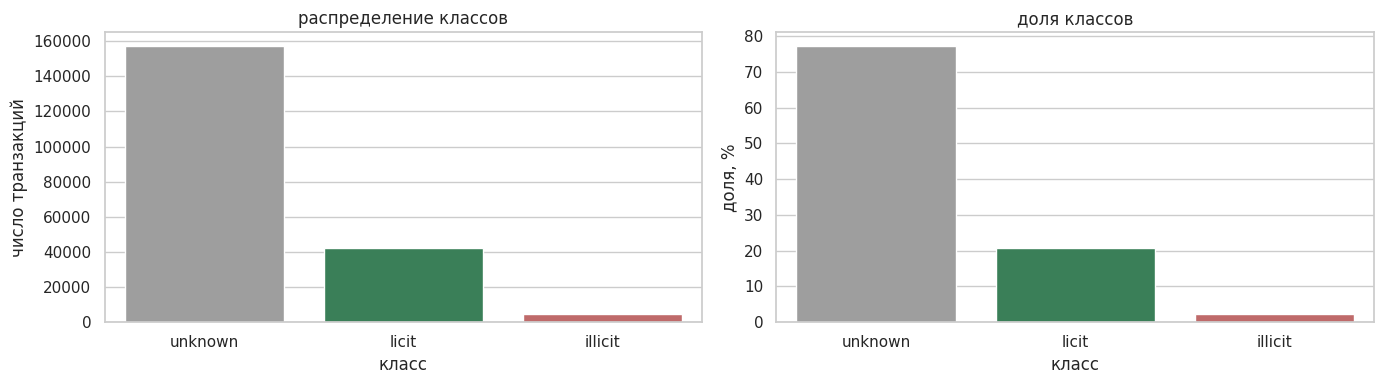

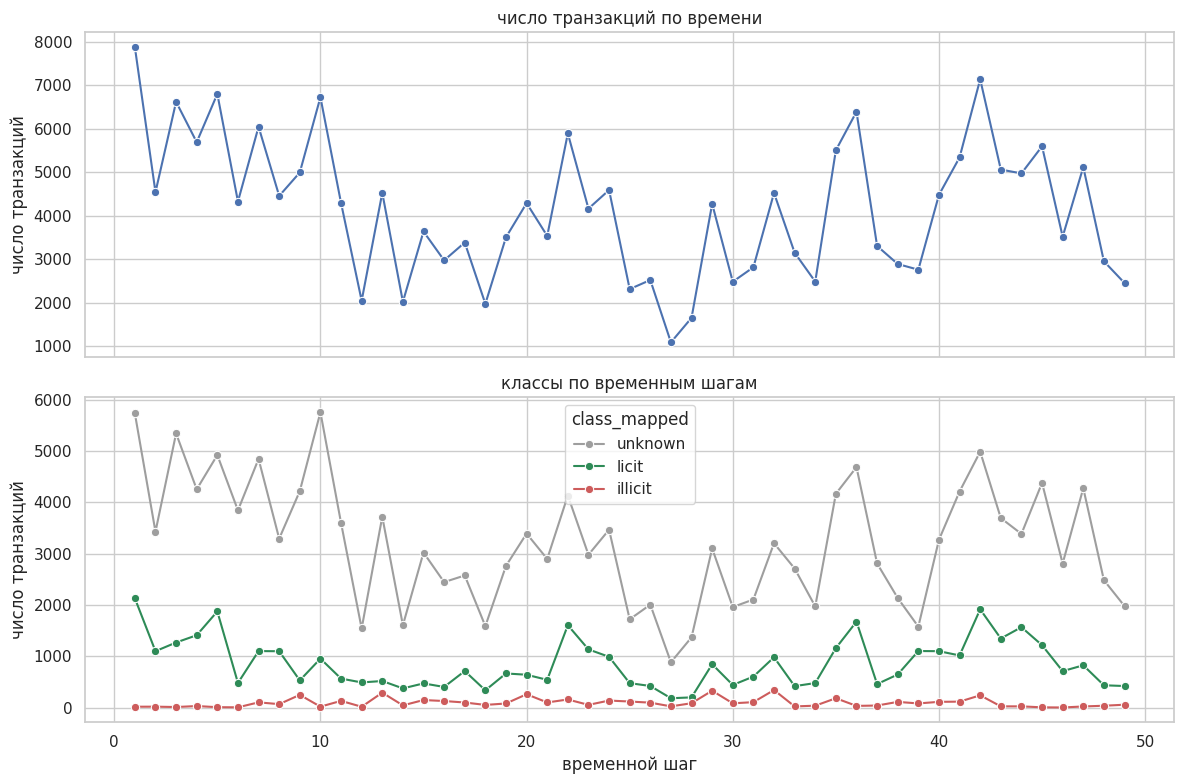

In [ ]:
# dataset_health_df проверяет базовую пригодность таблиц: пропуски и полные дубликаты строк.
dataset_health_df = pd.DataFrame(
    [
        {
            "table": "features_df",
            "missing_cells": int(features_df.isna().sum().sum()),
            "duplicate_rows": int(features_df.duplicated().sum()),
        },
        {
            "table": "classes_df",
            "missing_cells": int(classes_df.isna().sum().sum()),
            "duplicate_rows": int(classes_df.duplicated().sum()),
        },
        {
            "table": "edges_df",
            "missing_cells": int(edges_df.isna().sum().sum()),
            "duplicate_rows": int(edges_df.duplicated().sum()),
        },
    ]
)
display(dataset_health_df)
save_frame(dataset_health_df, "dataset_health.csv")

# class_summary_df показывает дисбаланс классов, важный для последующей постановки задачи классификации.
class_summary_df = (
    node_df["class_mapped"]
    .value_counts(dropna=False)
    .rename_axis("class_mapped")
    .reset_index(name="count")
)
class_summary_df["share_pct"] = 100 * class_summary_df["count"] / class_summary_df["count"].sum()
class_order = ["unknown", "licit", "illicit"]
class_summary_df["class_mapped"] = pd.Categorical(
    class_summary_df["class_mapped"],
    categories=class_order,
    ordered=True,
)
class_summary_df = class_summary_df.sort_values("class_mapped").reset_index(drop=True)
display(class_summary_df)
save_frame(class_summary_df, "class_summary.csv")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.barplot(
    data=class_summary_df,
    x="class_mapped",
    y="count",
    palette=["#9e9e9e", "#2e8b57", "#cd5c5c"],
    ax=axes[0],
)
axes[0].set_title("распределение классов")
axes[0].set_xlabel("класс")
axes[0].set_ylabel("число транзакций")

sns.barplot(
    data=class_summary_df,
    x="class_mapped",
    y="share_pct",
    palette=["#9e9e9e", "#2e8b57", "#cd5c5c"],
    ax=axes[1],
)
axes[1].set_title("доля классов")
axes[1].set_xlabel("класс")
axes[1].set_ylabel("доля, %")

plt.tight_layout()
render_figure(fig, "class_distribution.png")

# временная динамика общего потока и классов транзакций
step_summary_df = (
    node_df.groupby("time_step")
    .agg(node_count=("tx_id", "size"))
    .reset_index()
)
step_class_df = (
    node_df.groupby(["time_step", "class_mapped"])
    .size()
    .reset_index(name="count")
)

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

sns.lineplot(data=step_summary_df, x="time_step", y="node_count", marker="o", ax=axes[0])
axes[0].set_title("число транзакций по времени")
axes[0].set_xlabel("")
axes[0].set_ylabel("число транзакций")

sns.lineplot(
    data=step_class_df,
    x="time_step",
    y="count",
    hue="class_mapped",
    hue_order=class_order,
    marker="o",
    palette=["#9e9e9e", "#2e8b57", "#cd5c5c"],
    ax=axes[1],
)
axes[1].set_title("классы по временным шагам")
axes[1].set_xlabel("временной шаг")
axes[1].set_ylabel("число транзакций")

plt.tight_layout()
render_figure(fig, "temporal_structure.png")

## 4. Подготовка sample-графа

для визуализации строим подграф на стратифицированной выборке узлов. Это сохраняет классы и делает визуализации читаемыми.

In [6]:
# sampled_classes_df сохраняет пропорциональную выборку по классам, чтобы граф оставался читаемым.
sampled_classes_df = (
    classes_df.groupby("class_mapped", group_keys=False)
    .apply(lambda frame: frame.sample(frac=GRAPH_SAMPLE_FRAC, random_state=RANDOM_STATE))
    .reset_index(drop=True)
)
# sampled_tx_ids хранит выбранные транзакции и используется как фильтр для ребер и таблицы узлов.
sampled_tx_ids = set(sampled_classes_df["tx_id"].astype(int))

# sampled_edges_df оставляет ребра, где хотя бы один конец попал в выборку, как в исходном example-подходе.
sampled_edges_df = edges_df.loc[
    edges_df["tx_id_src"].isin(sampled_tx_ids)
    | edges_df["tx_id_dst"].isin(sampled_tx_ids)
].copy()

sampled_nodes_df = node_df.loc[node_df["tx_id"].isin(sampled_tx_ids)].copy()

# sample_graph является undirected-приближением для обзорной визуализации и метрик связности.
sample_graph = nx.from_pandas_edgelist(
    sampled_edges_df,
    source="tx_id_src",
    target="tx_id_dst",
    create_using=nx.Graph(),
)

sample_graph_summary_df = pd.DataFrame(
    [
        {
            "sample_frac": GRAPH_SAMPLE_FRAC,
            "sampled_nodes": len(sampled_nodes_df),
            "sampled_edges": len(sampled_edges_df),
            "graph_nodes": sample_graph.number_of_nodes(),
            "graph_edges": sample_graph.number_of_edges(),
            "connected_components": nx.number_connected_components(sample_graph),
        }
    ]
)
print(sampled_classes_df["class_mapped"].value_counts())
print(f"Sampled Edgelist: {len(sampled_edges_df):,}")
print(f"Sampled Features: {len(sampled_nodes_df):,}")
display(sample_graph_summary_df)
save_frame(sample_graph_summary_df, "sample_graph_summary.csv")

class_mapped
unknown    7860
licit      2101
illicit     227
Name: count, dtype: int64
Sampled Edgelist: 23,361
Sampled Features: 10,188


,sample_frac,sampled_nodes,sampled_edges,graph_nodes,graph_edges,connected_components
0,0.0500,10188,23361,30490,23361,7363


## 5. Базовые свойства графа

Здесь ключевые графики: размер графа и распределение степеней.

Таблица 2 — Базовые свойства sampled-графа.

Рисунок 3 — Базовые свойства sampled-графа и распределение степеней вершин.

Рисунок 4 — Распределение степеней вершин в log-log масштабе.

Число вершин: 10,188
Число рёбер: 23,361


,metric,value
0,число вершин,10188
1,число рёбер,23361


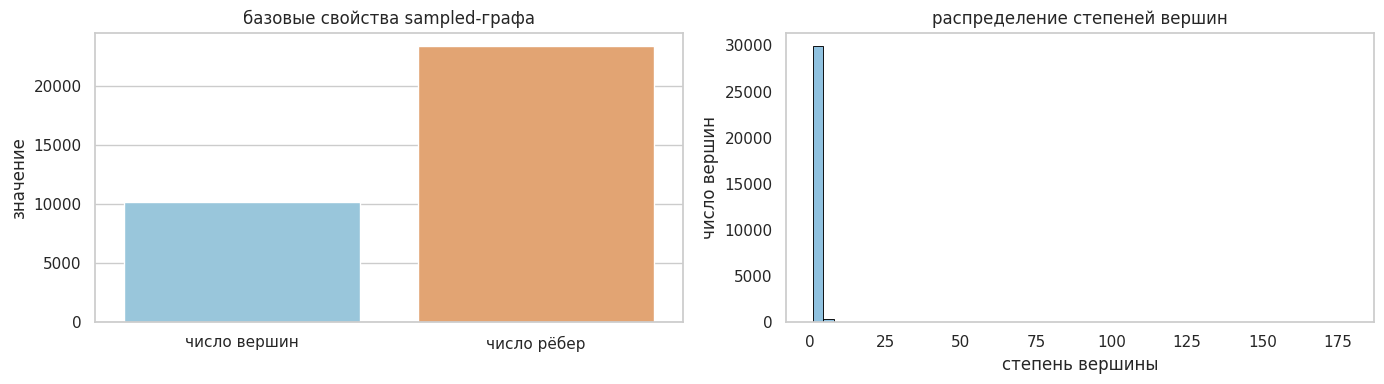

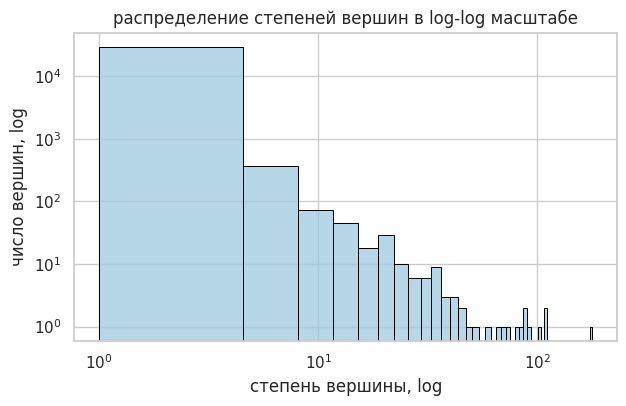

In [7]:
# num_nodes и num_edges фиксируют базовый масштаб sample-графа до расчета производных метрик.
num_nodes = len(sampled_nodes_df)
num_edges = len(sampled_edges_df)

# basic_graph_df собирает основные свойства графа для сравнения в тексте вкр.
basic_graph_df = pd.DataFrame(
    {
        "metric": ["число вершин", "число рёбер"],
        "value": [num_nodes, num_edges],
    }
)
print(f"Число вершин: {num_nodes:,}")
print(f"Число рёбер: {num_edges:,}")
display(basic_graph_df)
save_frame(basic_graph_df, "basic_graph_metrics.csv")

src_degree = sampled_edges_df["tx_id_src"].value_counts()
dst_degree = sampled_edges_df["tx_id_dst"].value_counts()
node_degree_series = src_degree.add(dst_degree, fill_value=0)
degree_df = pd.DataFrame({"degree": node_degree_series.to_numpy()})
log_degree_df = pd.DataFrame({"degree": [sample_graph.degree(node) for node in sample_graph.nodes()]})

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.barplot(data=basic_graph_df, x="metric", y="value", palette=["#8ecae6", "#f4a261"], ax=axes[0])
axes[0].set_title("базовые свойства sampled-графа")
axes[0].set_xlabel("")
axes[0].set_ylabel("значение")

sns.histplot(data=degree_df, x="degree", bins=50, color="#6baed6", edgecolor="black", ax=axes[1])
axes[1].set_title("распределение степеней вершин")
axes[1].set_xlabel("степень вершины")
axes[1].set_ylabel("число вершин")
axes[1].grid(False)

plt.tight_layout()
render_figure(fig, "basic_graph_properties.png")

fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(data=log_degree_df, x="degree", bins=50, color="#9ecae1", edgecolor="black", ax=ax)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_title("распределение степеней вершин в log-log масштабе")
ax.set_xlabel("степень вершины, log")
ax.set_ylabel("число вершин, log")
render_figure(fig, "degree_distribution_loglog.png")

## 6. Связность графа

Дальше смотрим, сколько компонент связности есть в sample-графе, и как устроена крупнейшая компонента.

Таблица 3 — Показатели связности sampled-графа.

Рисунок 5 — Связность sampled-графа и распределение длин кратчайших путей.

Число компонент связности: 7363
Крупнейшая компонента: число вершин = 417
Крупнейшая компонента: число рёбер = 428


,metric,value
0,connected_components,7363
1,giant_nodes,417
2,giant_edges,428


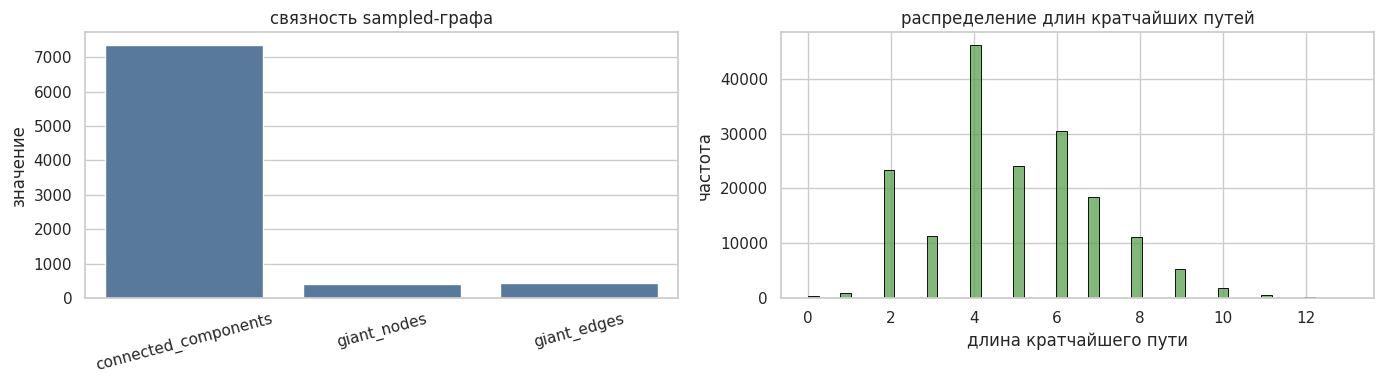

In [8]:
# connected_components показывает фрагментацию графа, а giant_graph выделяет крупнейшую компоненту для устойчивых метрик.
connected_components = list(nx.connected_components(sample_graph))
giant_nodes = max(connected_components, key=len)
giant_graph = sample_graph.subgraph(giant_nodes).copy()

print(f"Число компонент связности: {len(connected_components)}")
print(f"Крупнейшая компонента: число вершин = {giant_graph.number_of_nodes():,}")
print(f"Крупнейшая компонента: число рёбер = {giant_graph.number_of_edges():,}")

connectivity_df = pd.DataFrame(
    [
        {"metric": "connected_components", "value": len(connected_components)},
        {"metric": "giant_nodes", "value": giant_graph.number_of_nodes()},
        {"metric": "giant_edges", "value": giant_graph.number_of_edges()},
    ]
)
display(connectivity_df)
save_frame(connectivity_df, "connectivity_summary.csv")

# path_lengths хранит все кратчайшие пути внутри крупнейшей компоненты для оценки компактности графа.
path_lengths = dict(nx.shortest_path_length(giant_graph))
path_length_values = [
    length
    for target_lengths in path_lengths.values()
    for length in target_lengths.values()
]
path_length_df = pd.DataFrame({"path_length": path_length_values})

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.barplot(data=connectivity_df, x="metric", y="value", color="#4c78a8", ax=axes[0])
axes[0].set_title("связность sampled-графа")
axes[0].set_xlabel("")
axes[0].set_ylabel("значение")
axes[0].tick_params(axis="x", rotation=15)

sns.histplot(data=path_length_df, x="path_length", bins=50, color="#59a14f", edgecolor="black", ax=axes[1])
axes[1].set_title("распределение длин кратчайших путей")
axes[1].set_xlabel("длина кратчайшего пути")
axes[1].set_ylabel("частота")

plt.tight_layout()
render_figure(fig, "graph_connectivity.png")

## 7. Центральности узлов

Повторяем основной блок из example-ноутбука: degree, betweenness и closeness centrality. Для самой большой компоненты берём топ узлов и смотрим их отдельно.

Таблица 4 — Топ-10 вершин по центральностям.

Рисунок 6 — Топ-10 вершин по degree, betweenness и closeness centrality.

Рисунок 7 — Подграфы вершин с максимальными значениями центральностей.

Топ-10 вершин по degree centrality:
      tx_id  degree_centrality
0  12780176             0.2644
1  12665008             0.2236
2  12988705             0.0889
3  12804355             0.0529
4   9426022             0.0409
5   5663491             0.0337
6  13029248             0.0240
7  13365201             0.0168
8  12684016             0.0144
9  12987200             0.0144
Топ-10 вершин по betweenness centrality:
      tx_id  betweenness_centrality
0  12780176                  0.6276
1  12665008                  0.5112
2  12804355                  0.3639
3   5663491                  0.2489
4  12988705                  0.1832
5  12663816                  0.1801
6  12661072                  0.1781
7  12665054                  0.1592
8  12987200                  0.1115
9   9426022                  0.1037
Топ-10 вершин по closeness centrality:
      tx_id  closeness_centrality
0  12780176                0.3315
1  12665008                0.3144
2  12662969                0.2984
3  12665141

,tx_id,degree_centrality
0,12780176,0.2644
1,12665008,0.2236
2,12988705,0.0889
3,12804355,0.0529
4,9426022,0.0409
5,5663491,0.0337
6,13029248,0.0240
7,13365201,0.0168
8,12684016,0.0144
9,12987200,0.0144


,tx_id,betweenness_centrality
0,12780176,0.6276
1,12665008,0.5112
2,12804355,0.3639
3,5663491,0.2489
4,12988705,0.1832
5,12663816,0.1801
6,12661072,0.1781
7,12665054,0.1592
8,12987200,0.1115
9,9426022,0.1037


,tx_id,closeness_centrality
0,12780176,0.3315
1,12665008,0.3144
2,12662969,0.2984
3,12665141,0.2971
4,12665078,0.2959
5,12665086,0.2959
6,12665137,0.2959
7,12665171,0.2959
8,12804355,0.2847
9,13029248,0.2826


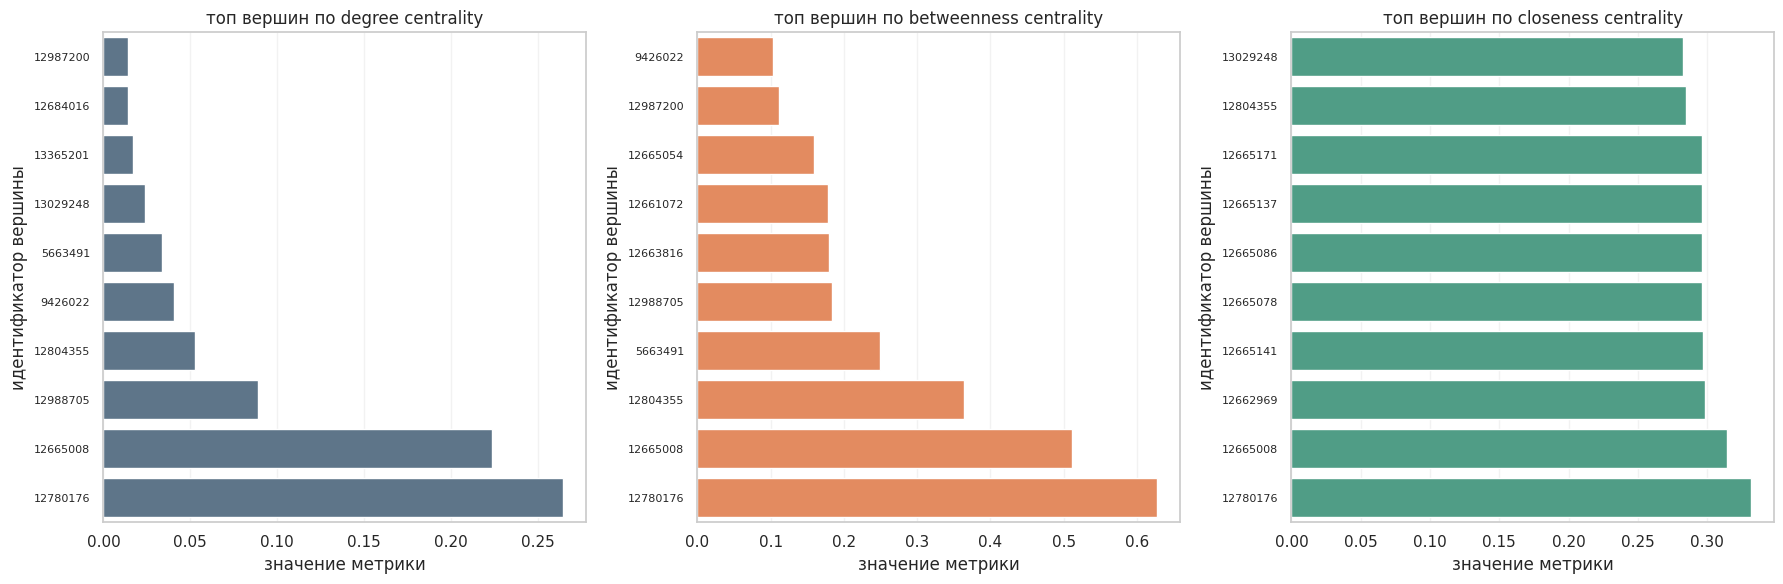

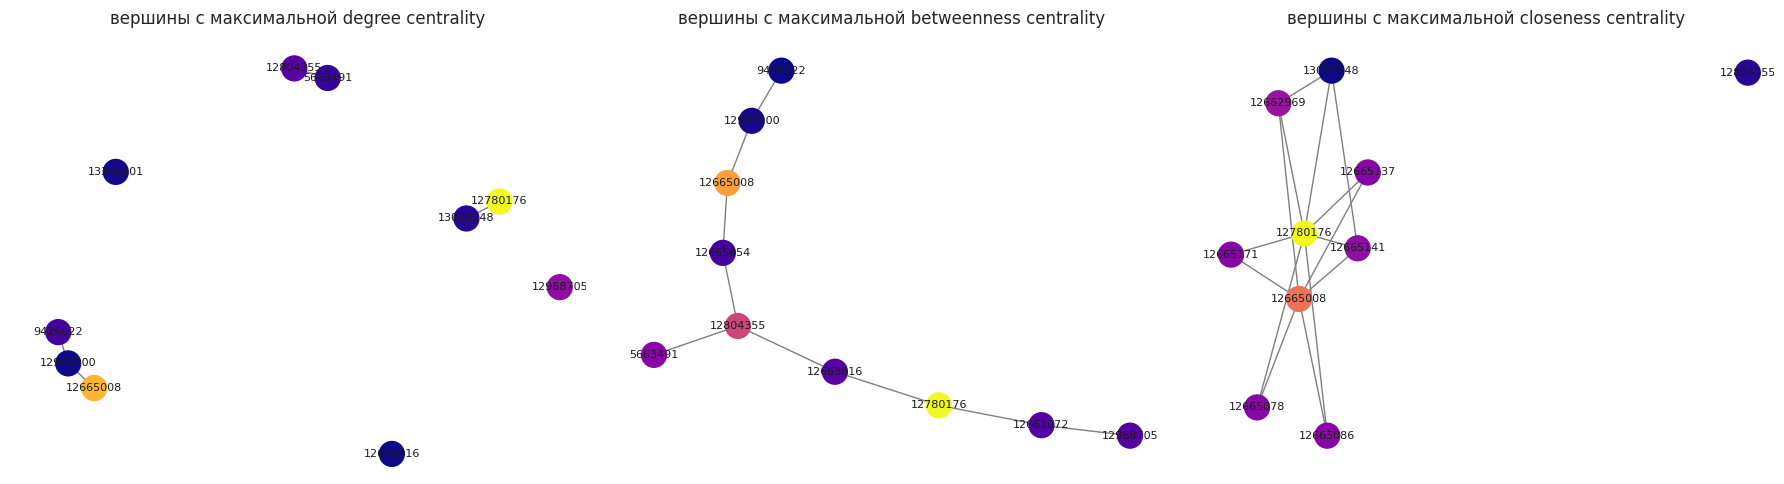

In [9]:
# центральности показывают разные роли узлов: связность, посредничество и близость к остальным вершинам.
degree_centrality = nx.degree_centrality(giant_graph)
betweenness_centrality = nx.betweenness_centrality(giant_graph)
closeness_centrality = nx.closeness_centrality(giant_graph)

# top-таблицы нужны для поиска наиболее важных транзакций по каждой графовой метрике.
degree_top_df = build_top_centrality_frame(degree_centrality, "degree_centrality")
betweenness_top_df = build_top_centrality_frame(
    betweenness_centrality,
    "betweenness_centrality",
)
closeness_top_df = build_top_centrality_frame(closeness_centrality, "closeness_centrality")

print("Топ-10 вершин по degree centrality:")
print(degree_top_df)
print("Топ-10 вершин по betweenness centrality:")
print(betweenness_top_df)
print("Топ-10 вершин по closeness centrality:")
print(closeness_top_df)

display(degree_top_df)
display(betweenness_top_df)
display(closeness_top_df)
save_frame(degree_top_df, "top_degree_centrality.csv")
save_frame(betweenness_top_df, "top_betweenness_centrality.csv")
save_frame(closeness_top_df, "top_closeness_centrality.csv")

# делаем компактные строковые подписи и сортируем значения для читаемого barplot
plot_specs = [
    (degree_top_df.copy(), "degree_centrality", "топ вершин по degree centrality", "#577590"),
    (betweenness_top_df.copy(), "betweenness_centrality", "топ вершин по betweenness centrality", "#f9844a"),
    (closeness_top_df.copy(), "closeness_centrality", "топ вершин по closeness centrality", "#43aa8b"),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (plot_df, metric_col, title, color) in zip(axes, plot_specs):
    plot_df = plot_df.sort_values(metric_col, ascending=True).copy()
    plot_df["tx_id_label"] = plot_df["tx_id"].astype(str)

    sns.barplot(
        data=plot_df,
        x=metric_col,
        y="tx_id_label",
        orient="h",
        color=color,
        ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel("значение метрики")
    ax.set_ylabel("идентификатор вершины")
    ax.tick_params(axis="y", labelsize=8)
    ax.grid(axis="x", alpha=0.25)

plt.tight_layout()
render_figure(fig, "top_centrality_barplots.png")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
centrality_specs = [
    (degree_top_df, degree_centrality, "вершины с максимальной degree centrality", axes[0]),
    (betweenness_top_df, betweenness_centrality, "вершины с максимальной betweenness centrality", axes[1]),
    (closeness_top_df, closeness_centrality, "вершины с максимальной closeness centrality", axes[2]),
]

for top_df, centrality_map, title, ax in centrality_specs:
    subgraph_nodes = top_df["tx_id"].tolist()
    subgraph = giant_graph.subgraph(subgraph_nodes).copy()
    subgraph_pos = nx.spring_layout(subgraph, seed=RANDOM_STATE)
    scores = [centrality_map[node] for node in subgraph.nodes()]
    nx.draw_networkx(
        subgraph,
        pos=subgraph_pos,
        with_labels=True,
        node_size=320,
        font_size=8,
        edge_color="#7f7f7f",
        node_color=scores,
        cmap="plasma",
        ax=ax,
    )
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
render_figure(fig, "top_centrality_subgraphs.png")

## 8. Пересечение центральностей

Покажем, какие узлы одновременно попадают в топ разных центральностей.

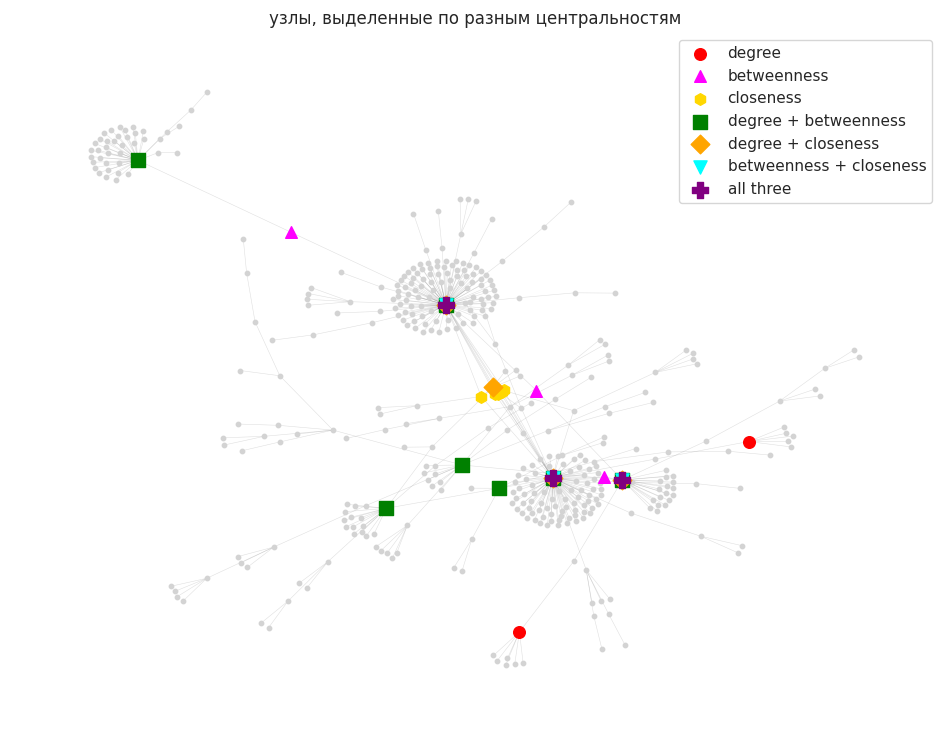

In [10]:
# множества top_nodes_* нужны, чтобы увидеть пересечение ролей одного узла в разных центральностях.
top_nodes_degree = set(degree_top_df["tx_id"].tolist())
top_nodes_betweenness = set(betweenness_top_df["tx_id"].tolist())
top_nodes_closeness = set(closeness_top_df["tx_id"].tolist())

top_nodes_both = top_nodes_degree & top_nodes_betweenness
top_nodes_closeness_and_degree = top_nodes_closeness & top_nodes_degree
top_nodes_closeness_and_betweenness = top_nodes_closeness & top_nodes_betweenness
top_nodes_all_three = (
    top_nodes_closeness & top_nodes_degree & top_nodes_betweenness
)

giant_pos = nx.spring_layout(giant_graph, seed=RANDOM_STATE)

fig, ax = plt.subplots(figsize=(12, 9))
nx.draw_networkx_nodes(giant_graph, giant_pos, node_color="lightgray", node_size=10, ax=ax)
nx.draw_networkx_edges(giant_graph, giant_pos, width=0.4, edge_color="gray", alpha=0.25, ax=ax)

nx.draw_networkx_nodes(
    giant_graph,
    giant_pos,
    nodelist=list(top_nodes_degree - top_nodes_both - top_nodes_closeness_and_degree),
    node_color="red",
    node_shape="o",
    node_size=70,
    label="degree",
    ax=ax,
)
nx.draw_networkx_nodes(
    giant_graph,
    giant_pos,
    nodelist=list(top_nodes_betweenness - top_nodes_both - top_nodes_closeness_and_betweenness),
    node_color="magenta",
    node_shape="^",
    node_size=70,
    label="betweenness",
    ax=ax,
)
nx.draw_networkx_nodes(
    giant_graph,
    giant_pos,
    nodelist=list(top_nodes_closeness - top_nodes_closeness_and_degree - top_nodes_closeness_and_betweenness),
    node_color="gold",
    node_shape="h",
    node_size=70,
    label="closeness",
    ax=ax,
)
nx.draw_networkx_nodes(
    giant_graph,
    giant_pos,
    nodelist=list(top_nodes_both),
    node_color="green",
    node_shape="s",
    node_size=90,
    label="degree + betweenness",
    ax=ax,
)
nx.draw_networkx_nodes(
    giant_graph,
    giant_pos,
    nodelist=list(top_nodes_closeness_and_degree),
    node_color="orange",
    node_shape="D",
    node_size=90,
    label="degree + closeness",
    ax=ax,
)
nx.draw_networkx_nodes(
    giant_graph,
    giant_pos,
    nodelist=list(top_nodes_closeness_and_betweenness),
    node_color="cyan",
    node_shape="v",
    node_size=90,
    label="betweenness + closeness",
    ax=ax,
)
nx.draw_networkx_nodes(
    giant_graph,
    giant_pos,
    nodelist=list(top_nodes_all_three),
    node_color="purple",
    node_shape="P",
    node_size=120,
    label="all three",
    ax=ax,
)

ax.set_title("узлы, выделенные по разным центральностям")
ax.axis("off")
ax.legend(loc="upper right")
render_figure(fig, "centrality_overlap_graph.png")

## 9. Подграфы по классам

class-specific анализ полезен не для классификации как таковой, а для понимания того, насколько по-разному могут выглядеть подсети licit и illicit транзакций.

Таблица 5 — Сводка по подграфам классов.

Рисунок 8 — Подграфы licit и illicit транзакций.

,class,nodes,edges,density
0,illicit,227,1,0.0000
1,licit,2101,92,0.0000


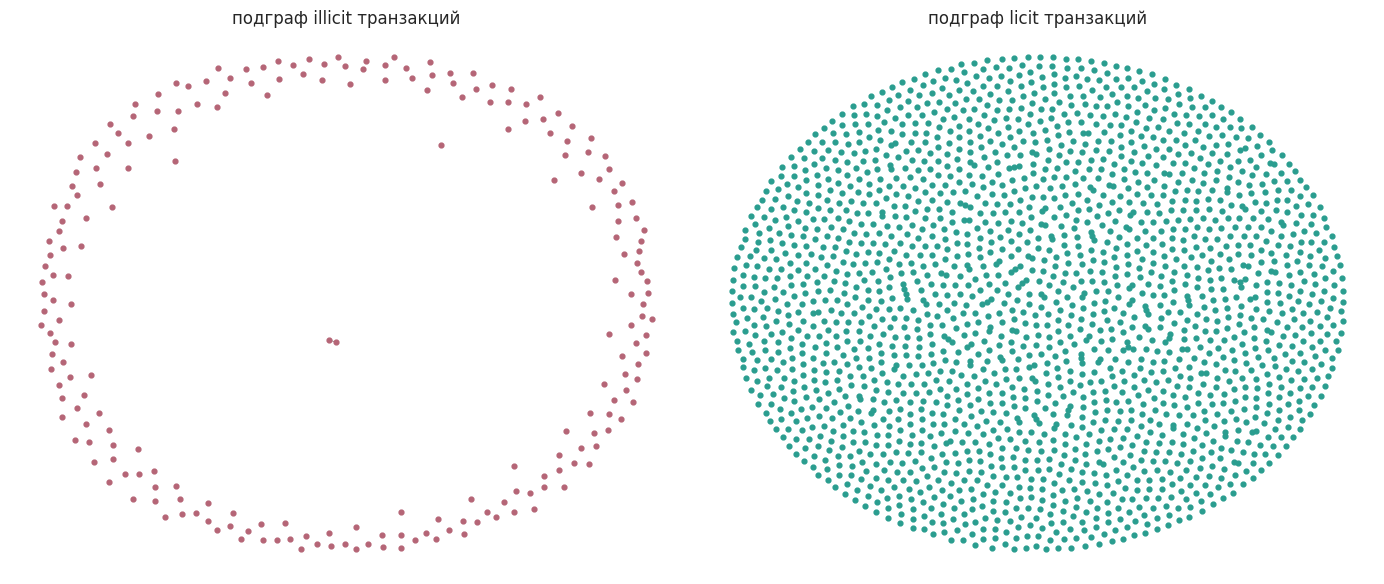

In [11]:
# illicit_nodes и licit_nodes разделяют sample-граф по классу для сравнения плотности и структуры подграфов.
illicit_nodes = sampled_classes_df.loc[
    sampled_classes_df["class_mapped"] == "illicit",
    "tx_id",
].tolist()
licit_nodes = sampled_classes_df.loc[
    sampled_classes_df["class_mapped"] == "licit",
    "tx_id",
].tolist()

illicit_graph = sample_graph.subgraph(illicit_nodes).copy()
licit_graph = sample_graph.subgraph(licit_nodes).copy()

# class_subgraph_df хранит сравнимые показатели подграфов: число вершин, ребер и плотность.
class_subgraph_df = pd.DataFrame(
    [
        {
            "class": "illicit",
            "nodes": illicit_graph.number_of_nodes(),
            "edges": illicit_graph.number_of_edges(),
            "density": nx.density(illicit_graph) if illicit_graph.number_of_nodes() > 1 else 0.0,
        },
        {
            "class": "licit",
            "nodes": licit_graph.number_of_nodes(),
            "edges": licit_graph.number_of_edges(),
            "density": nx.density(licit_graph) if licit_graph.number_of_nodes() > 1 else 0.0,
        },
    ]
)
display(class_subgraph_df)
save_frame(class_subgraph_df, "class_subgraph_summary.csv")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

illicit_pos = nx.spring_layout(illicit_graph, seed=RANDOM_STATE) if illicit_graph.number_of_nodes() else {}
licit_pos = nx.spring_layout(licit_graph, seed=RANDOM_STATE) if licit_graph.number_of_nodes() else {}

nx.draw(
    illicit_graph,
    pos=illicit_pos,
    with_labels=False,
    node_size=12,
    node_color="#b56576",
    edge_color="#444444",
    width=0.4,
    ax=axes[0],
)
axes[0].set_title("подграф illicit транзакций")
axes[0].axis("off")

nx.draw(
    licit_graph,
    pos=licit_pos,
    with_labels=False,
    node_size=12,
    node_color="#2a9d8f",
    edge_color="#444444",
    width=0.4,
    ax=axes[1],
)
axes[1].set_title("подграф licit транзакций")
axes[1].axis("off")

plt.tight_layout()
render_figure(fig, "class_specific_subgraphs.png")

## 10. Сообщества в графе

Проведем community detection. Здесь мы раскрашиваем крупнейшую компоненту по найденным сообществам.

Таблица 6 — Размеры крупнейших сообществ.

Рисунок 9 — Размеры крупнейших сообществ и сообщества в крупнейшей компоненте.

Рисунок 10 — Выделение сообществ в крупнейшей компоненте графа.

,community_id,node_count
0,3,102
1,11,83
2,12,42
3,9,35
4,5,32
5,4,25
6,10,20
7,13,14
8,2,13
9,1,11


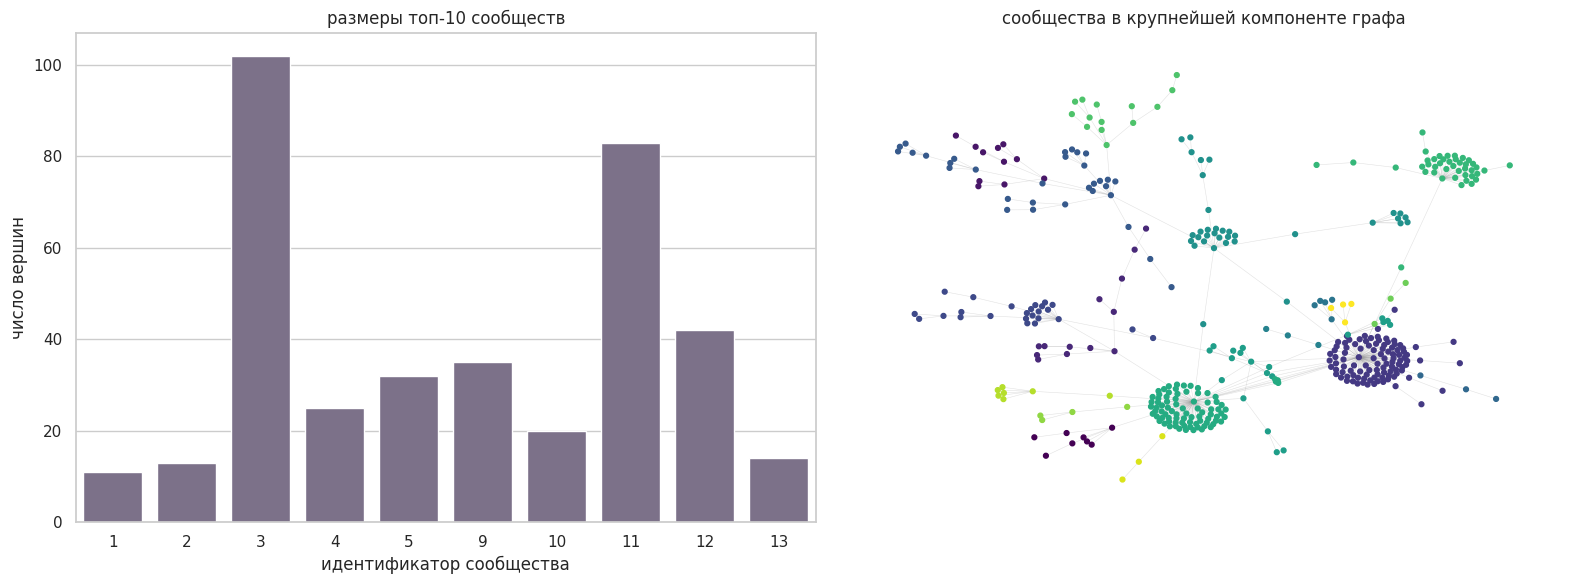

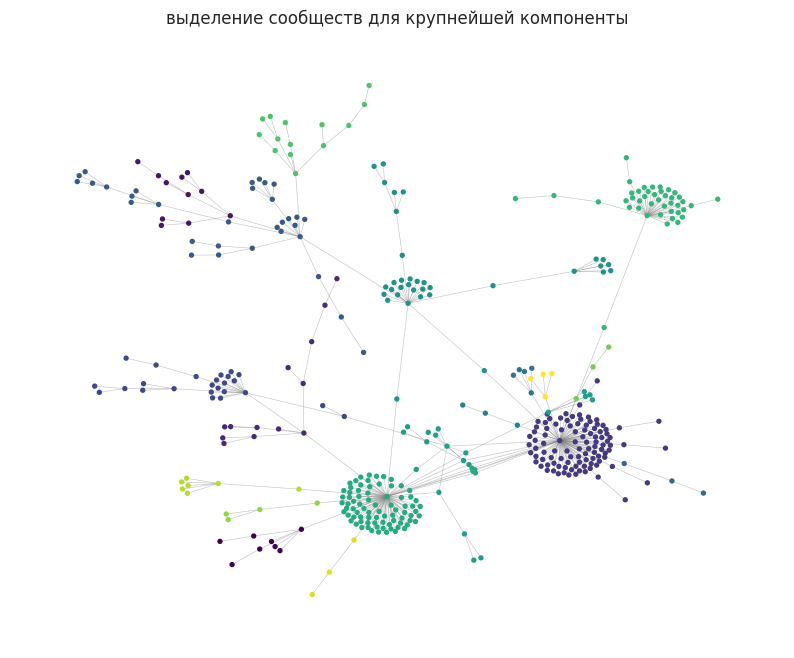

In [12]:
# этап community detection проверяет гипотезу о кластерной структуре транзакционного графа.
try:
    from community import community_louvain
    partition = community_louvain.best_partition(giant_graph)
    community_map = {int(node): int(group_id) for node, group_id in partition.items()}
except ImportError:
    if hasattr(nx_community, "louvain_communities"):
        communities = nx_community.louvain_communities(giant_graph, seed=RANDOM_STATE)
    else:
        communities = list(nx_community.greedy_modularity_communities(giant_graph))
    community_map = assign_community_ids(communities)

# community_df связывает каждую вершину крупнейшей компоненты с найденным номером сообщества.
community_df = pd.DataFrame(
    {
        "tx_id": list(community_map.keys()),
        "community_id": list(community_map.values()),
    }
)
community_summary_df = (
    community_df["community_id"]
    .value_counts()
    .rename_axis("community_id")
    .reset_index(name="node_count")
    .sort_values("node_count", ascending=False)
    .reset_index(drop=True)
)
display(community_summary_df.head(10))
save_frame(community_summary_df, "community_summary.csv")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(
    data=community_summary_df.head(10),
    x="community_id",
    y="node_count",
    color="#7b6d8d",
    ax=axes[0],
)
axes[0].set_title("размеры топ-10 сообществ")
axes[0].set_xlabel("идентификатор сообщества")
axes[0].set_ylabel("число вершин")

community_pos = nx.spring_layout(giant_graph)
node_colors = [community_map.get(node, -1) for node in giant_graph.nodes()]
nx.draw_networkx_nodes(
    giant_graph,
    community_pos,
    node_color=node_colors,
    cmap=plt.cm.viridis,
    node_size=12,
    ax=axes[1],
)
nx.draw_networkx_edges(
    giant_graph,
    community_pos,
    edge_color="#8a8a8a",
    alpha=0.25,
    width=0.4,
    ax=axes[1],
)
axes[1].set_title("сообщества в крупнейшей компоненте графа")
axes[1].axis("off")

plt.tight_layout()
render_figure(fig, "community_detection.png")

fig, ax = plt.subplots(figsize=(10, 8))
nx.draw_networkx_nodes(
    giant_graph,
    community_pos,
    node_color=node_colors,
    node_size=8,
    cmap=plt.cm.viridis,
    ax=ax,
)
nx.draw_networkx_edges(
    giant_graph,
    community_pos,
    alpha=0.5,
    edge_color="#7f7f7f",
    width=0.4,
    ax=ax,
)
ax.set_title("выделение сообществ для крупнейшей компоненты")
ax.axis("off")
render_figure(fig, "community_detection_full_graph.png")

## 11. T-SNE по признакам узлов

Для диплома полезно показать не только структуру рёбер, но и геометрию самих признаков узлов. Ниже строится `t-SNE` по tabular-признакам Elliptic.

Логика такая:
- стандартизуем признаки;
- сначала сжимаем пространство через `PCA`;
- затем строим `t-SNE`;
- цветом показываем класс узла.

Рисунок 11 — T-SNE визуализация признаков узлов.

Рисунок 12 — T-SNE визуализация признаков узлов на подвыборке.

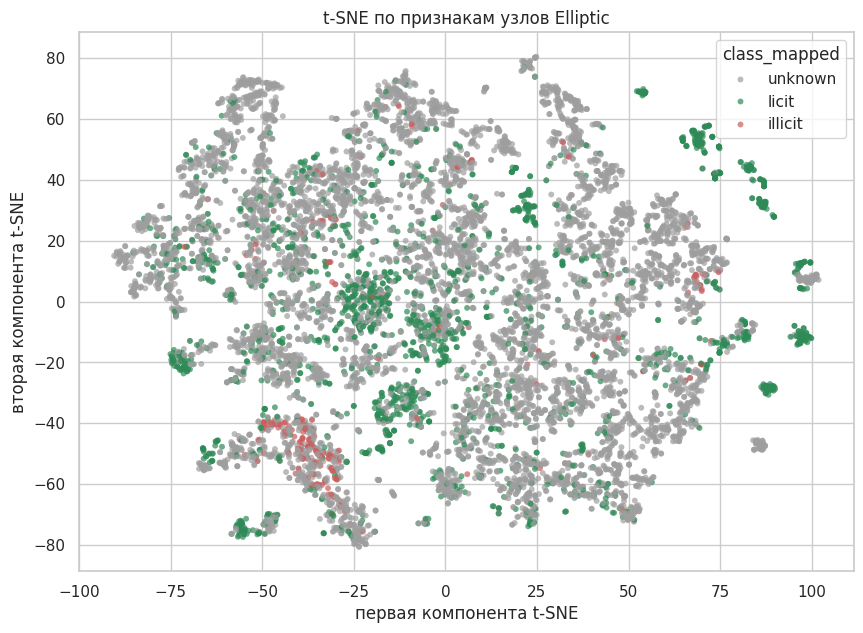

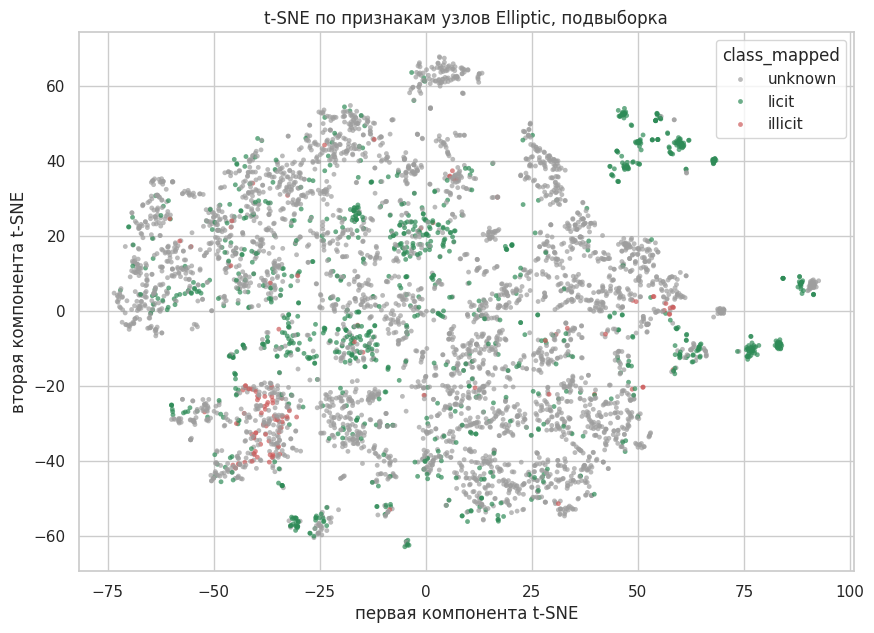

In [13]:
# tsne_source_df содержит узлы с известной группой для проверки визуальной разделимости классов.
tsne_source_df = sampled_nodes_df.loc[
    sampled_nodes_df["class_mapped"].isin(["licit", "illicit", "unknown"])
].copy()

# tsne_feature_matrix хранит стандартизованные признаки, которые подаются в pca и затем в t-sne.
tsne_feature_matrix = tsne_source_df[feature_cols].fillna(0).to_numpy(dtype=np.float32)
tsne_feature_matrix = StandardScaler().fit_transform(tsne_feature_matrix)

# pca снижает размерность перед t-sne, чтобы ускорить расчет и уменьшить шум в признаках.
pca_components = min(30, tsne_feature_matrix.shape[1], max(tsne_feature_matrix.shape[0] - 1, 1))
pca = PCA(n_components=pca_components, random_state=RANDOM_STATE)
embeddings = pca.fit_transform(tsne_feature_matrix)

# class_to_id задает числовое кодирование классов для совместимости с алгоритмами и графиками.
class_to_id = {"unknown": 0, "licit": 1, "illicit": 2}
tsne_source_df["class_id"] = tsne_source_df["class_mapped"].map(class_to_id)

cpu_tsne = TSNE(
    n_components=2,
    random_state=RANDOM_STATE,
    init="pca",
    learning_rate="auto",
    perplexity=30,
)
embeddings_2d = cpu_tsne.fit_transform(embeddings)

tsne_cpu_df = pd.DataFrame(
    {
        "tsne_1": embeddings_2d[:, 0],
        "tsne_2": embeddings_2d[:, 1],
        "class_mapped": tsne_source_df["class_mapped"].to_numpy(),
    }
)

fig, ax = plt.subplots(figsize=(10, 7))
sns.scatterplot(
    data=tsne_cpu_df,
    x="tsne_1",
    y="tsne_2",
    hue="class_mapped",
    hue_order=["unknown", "licit", "illicit"],
    palette={"unknown": "#9e9e9e", "licit": "#2e8b57", "illicit": "#cd5c5c"},
    alpha=0.7,
    s=18,
    linewidth=0,
    ax=ax,
)
ax.set_title("t-SNE по признакам узлов Elliptic")
ax.set_xlabel("первая компонента t-SNE")
ax.set_ylabel("вторая компонента t-SNE")
render_figure(fig, "tsne_full_sample.png")

# подвыборка ускоряет повторный t-sne и помогает проверить, сохраняется ли картина на меньшем числе узлов.
subset_size = min(5000, len(embeddings))
subset_indices = np.random.choice(len(embeddings), subset_size, replace=False)
embeddings_subset = embeddings[subset_indices]
labels_subset = tsne_source_df.iloc[subset_indices]["class_mapped"].to_numpy()

cpu_tsne_subset = TSNE(
    n_components=2,
    random_state=RANDOM_STATE,
    init="pca",
    learning_rate="auto",
    perplexity=30,
)
embeddings_2d_subset = cpu_tsne_subset.fit_transform(embeddings_subset)

tsne_subset_df = pd.DataFrame(
    {
        "tsne_1": embeddings_2d_subset[:, 0],
        "tsne_2": embeddings_2d_subset[:, 1],
        "class_mapped": labels_subset,
    }
)

fig, ax = plt.subplots(figsize=(10, 7))
sns.scatterplot(
    data=tsne_subset_df,
    x="tsne_1",
    y="tsne_2",
    hue="class_mapped",
    hue_order=["unknown", "licit", "illicit"],
    palette={"unknown": "#9e9e9e", "licit": "#2e8b57", "illicit": "#cd5c5c"},
    alpha=0.7,
    s=12,
    linewidth=0,
    ax=ax,
)
ax.set_title("t-SNE по признакам узлов Elliptic, подвыборка")
ax.set_xlabel("первая компонента t-SNE")
ax.set_ylabel("вторая компонента t-SNE")
render_figure(fig, "tsne_subsampled.png")

## 12. GPU-ускоренный T-SNE

Рисунок 13 — GPU-ускоренная T-SNE визуализация признаков узлов.

In [14]:
# проверка gpu нужна перед запуском ускоренного t-sne через cuml.
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "no gpu")

True
Tesla T4


[2026-04-25 13:40:38.887] [CUML] [warning] # of Nearest Neighbors should be at least 3 * perplexity. Your results might be a bit strange...


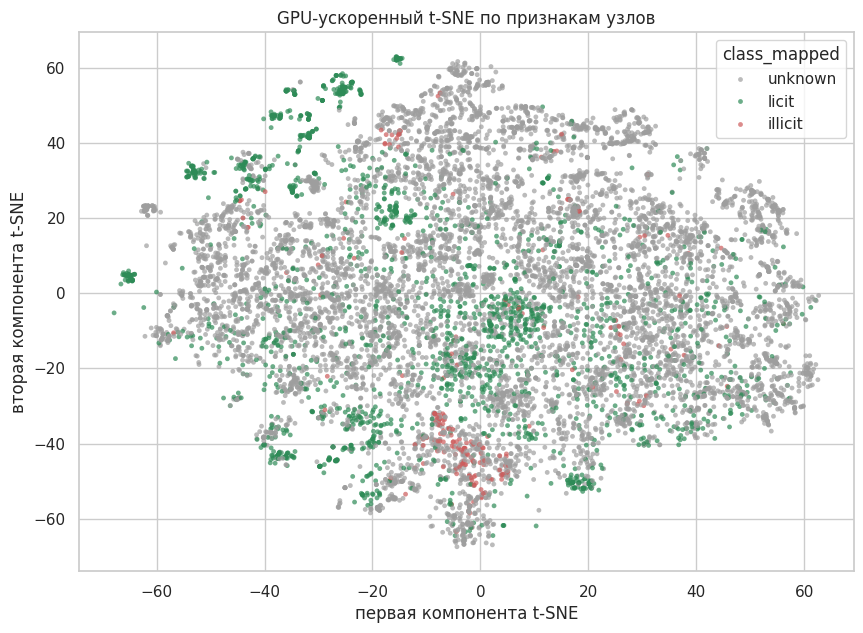

In [15]:
# gpu-ветка повторяет t-sne на тех же embeddings, но выполняется только при доступном cuml.
try:
    from cuml.manifold import TSNE as cuTSNE

    gpu_tsne = cuTSNE(n_components=2, random_state=RANDOM_STATE)
    embeddings_2d_gpu = gpu_tsne.fit_transform(embeddings)

    tsne_gpu_df = pd.DataFrame(
        {
            "tsne_1": np.asarray(embeddings_2d_gpu)[:, 0],
            "tsne_2": np.asarray(embeddings_2d_gpu)[:, 1],
            "class_mapped": tsne_source_df["class_mapped"].to_numpy(),
        }
    )

    fig, ax = plt.subplots(figsize=(10, 7))
    sns.scatterplot(
        data=tsne_gpu_df,
        x="tsne_1",
        y="tsne_2",
        hue="class_mapped",
        hue_order=["unknown", "licit", "illicit"],
        palette={"unknown": "#9e9e9e", "licit": "#2e8b57", "illicit": "#cd5c5c"},
        alpha=0.7,
        s=12,
        linewidth=0,
        ax=ax,
    )
    ax.set_title("GPU-ускоренный t-SNE по признакам узлов")
    ax.set_xlabel("первая компонента t-SNE")
    ax.set_ylabel("вторая компонента t-SNE")
    render_figure(fig, "tsne_gpu.png")
except ImportError:
    print("cuML недоступен, GPU t-SNE пропущен")

## 13. Выводы

При чтении этих графиков полезно отдельно отметить:
- сильный дисбаланс между `unknown`, `licit` и `illicit`;
- неравномерность по `time_step`;
- тяжёлый хвост в распределении степеней;
- наличие крупной компоненты и множества мелких;
- различия между licit и illicit подграфами;
- существование выраженной внутренней структуры в виде сообществ;
- степень разделимости классов в пространстве исходных признаков через `t-SNE`

In [16]:
# архив собирает результаты kaggle-сессии для скачивания графиков и таблиц одним файлом.
import shutil

shutil.make_archive('/kaggle/working/archive', 'zip', '/kaggle/working/')

'/kaggle/working/archive.zip'